# Inspect M0 and regularized M1 counterfactual radiance

This notebook inspects **non-gap-filled, quality-screened VNP46A2 Collection 002** predictions on the native grid. It reads the offline outputs of `.venv/bin/python scripts/run_counterfactual.py`; it does not fit models, make network requests, or read TING.

M0 is the pre-event median with robust, pooled variability. M1 is a strongly constrained local-level state-space model with no trend or seasonality. Both models are fit before April 2; event measurements never update their expected normal brightness.

**These are radiance forecasts and anomaly diagnostics, not outage classifications.** The nominal 90% intervals and lower-tail scores require checking against held-out observations. Product dates are not exact local overpass timestamps. Use the project `.venv` kernel and Run All.

In [1]:
import os
import tempfile
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'ntl-matplotlib'))
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from rasterio.transform import Affine, rowcol
%matplotlib inline

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'scripts/run_counterfactual.py').exists())
sys.path.insert(0, str(ROOT))
from scripts.ingest_viirs import digest
OUTPUT = ROOT / 'data/published/counterfactual_dyer'
manifest = json.loads((OUTPUT / 'manifest.json').read_text())
assert manifest['status'] == 'complete', 'Run the pipeline to completion first'
for name in ['analysis_arrays.npz', 'cells.csv', 'validation_summary.csv', 'validation_daily.csv', 'event_daily_summary.csv', 'model_details.json']:
    assert digest(OUTPUT / name) == manifest['output_sha256'][name], f'Output changed: {name}'
arrays = np.load(OUTPUT / 'analysis_arrays.npz', allow_pickle=False)
cells = pd.read_csv(OUTPUT / 'cells.csv')
validation = pd.read_csv(OUTPUT / 'validation_summary.csv')
validation_daily = pd.read_csv(OUTPUT / 'validation_daily.csv')
event_summary = pd.read_csv(OUTPUT / 'event_daily_summary.csv')
details = json.loads((OUTPUT / 'model_details.json').read_text())
dates = pd.DatetimeIndex(arrays['dates'])
cutoff = int(arrays['cutoff'])
event_dates = dates[cutoff:]
observed = arrays['observed']
county = arrays['county']
affine = Affine(*arrays['transform'])
print('Kernel:', sys.executable)
print('Settings:', details['settings'])
print(f"Supported cells: {details['supported_cells']:,} / {details['county_cells']:,}")
print('Forecast dates:', details['forecast_start'], 'through', details['forecast_end'])
print(details['intervals'])

Kernel: /home/daynan/research/ntl-outage-detection/.venv/bin/python
Settings: {'min_observations': 10, 'scale_floor': 0.1, 'scale_prior_weight': 20, 'process_ratio': 0.001}
Supported cells: 7,688 / 7,868
Forecast dates: 2025-04-02 through 2025-04-17
Central 90% uncalibrated Student-t predictive references; may extend below zero.


## Pre-event forecasting: does M1 improve over M0?

Each fold trains on at least 28 calendar days, then forecasts an entire withheld 7- or 14-day block without updating from that block. No future observations contribute to training or scale pooling. Targets do not overlap **within** each design; the two designs reuse dates and must be interpreted separately.

The table pools scored cell-nights within a design. Coverage should approach 90%, with about 5% of observations below the lower bound under a well-calibrated reference. Lower MAE, RMSE, and interval score are better. Thousands of neighboring cells are dependent; these are descriptive scores without independence-based confidence bounds. Bias is observed minus predicted radiance.

In [2]:
def aggregate_scores(frame, groups):
    rows = []
    for keys, part in frame.loc[frame['n'] > 0].groupby(groups):
        if not isinstance(keys, tuple): keys = (keys,)
        row = dict(zip(groups, keys))
        weights = part['n'].to_numpy()
        row['scored_cell_nights'] = int(weights.sum())
        for key in ['mae', 'bias', 'coverage90', 'below_q05', 'mean_interval_width', 'interval_score90']:
            row[key] = np.average(part[key], weights=weights)
        row['rmse'] = np.sqrt(np.average(part['rmse']**2, weights=weights))
        rows.append(row)
    return pd.DataFrame(rows)

all_strata = validation[validation['stratum'] == 'all']
scores = aggregate_scores(all_strata, ['design', 'method'])
display(scores.round(4))
display(all_strata[['design', 'method', 'train_end', 'test_start', 'test_end', 'eligible_cells', 'n', 'coverage90', 'below_q05']].round(4))
print('Eligibility may be substantially lower in early folds because the training history is short.')

,design,method,scored_cell_nights,mae,bias,coverage90,below_q05,mean_interval_width,interval_score90,rmse
0,14d,M0,106070,0.7808,0.1979,0.8654,0.0172,2.5033,5.3964,2.9449
1,14d,M1,106070,0.7936,0.0189,0.8797,0.0224,2.7955,4.7313,2.8889
2,7d,M0,108468,0.7701,0.1737,0.8697,0.0223,2.5068,5.2400,2.9377
3,7d,M1,108468,0.7805,-0.0000,0.8886,0.0220,2.8077,4.6049,2.8674


,design,method,train_end,test_start,test_end,eligible_cells,n,coverage90,below_q05
0,7d,M0,2025-03-04,2025-03-05,2025-03-11,6593,27498,0.9530,0.0173
4,7d,M1,2025-03-04,2025-03-05,2025-03-11,6593,27498,0.9530,0.0239
8,7d,M0,2025-03-11,2025-03-12,2025-03-18,7548,18842,0.8927,0.0887
12,7d,M1,2025-03-11,2025-03-12,2025-03-18,7548,18842,0.9089,0.0776
16,7d,M0,2025-03-18,2025-03-19,2025-03-25,7600,27548,0.8475,0.0045
20,7d,M1,2025-03-18,2025-03-19,2025-03-25,7600,27548,0.8726,0.0036
24,7d,M0,2025-03-25,2025-03-26,2025-04-01,7650,34580,0.8087,0.0042
28,7d,M1,2025-03-25,2025-03-26,2025-04-01,7650,34580,0.8390,0.0047
32,14d,M0,2025-03-04,2025-03-05,2025-03-18,6593,44092,0.9407,0.0348
36,14d,M1,2025-03-04,2025-03-05,2025-03-18,6593,44092,0.9338,0.0477


Eligibility may be substantially lower in early folds because the training history is short.


## Calibration by brightness and forecast horizon

Brightness groups are defined using each fold's training median, not event dimming: dim <1, moderate 1–5, bright ≥5 nW cm⁻² sr⁻¹. These are diagnostic strata, not outage-detectability thresholds. Inspect bright cells separately because the county-wide score can be dominated by dim cells.

All intervals below are the original model intervals. No multiplier or threshold has been tuned using these evaluation observations.

,design,method,stratum,scored_cell_nights,mae,bias,coverage90,below_q05,mean_interval_width,interval_score90,rmse
0,14d,M0,bright_ge5,4885,7.9475,1.2961,0.7107,0.1056,21.2644,58.5244,12.8803
1,14d,M0,dim_lt1,81744,0.3532,0.1186,0.8694,0.0134,1.3076,2.1308,0.8653
2,14d,M0,moderate_1to5,19441,0.7779,0.2553,0.8871,0.0109,2.8169,5.7778,1.5753
3,14d,M1,bright_ge5,4885,8.0764,-0.8000,0.7646,0.1079,25.0323,47.4918,12.6218
4,14d,M1,dim_lt1,81744,0.3557,0.0697,0.8775,0.0192,1.3594,2.0735,0.8762
5,14d,M1,moderate_1to5,19441,0.8051,0.0112,0.9183,0.0145,3.2465,5.1620,1.5088
6,7d,M0,bright_ge5,5141,7.8408,1.1096,0.7209,0.1029,21.3247,56.2711,12.7119
7,7d,M0,dim_lt1,83537,0.3385,0.0993,0.8742,0.0196,1.2860,2.0374,0.8535
8,7d,M0,moderate_1to5,19790,0.7553,0.2445,0.8894,0.0128,2.7714,5.5020,1.4997
9,7d,M1,bright_ge5,5141,7.9414,-0.8585,0.7724,0.1070,24.9585,46.0055,12.3884


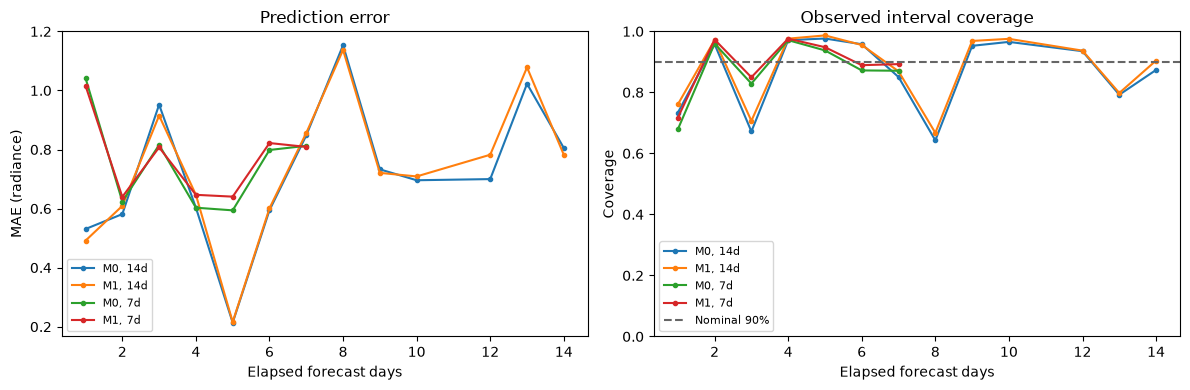

In [3]:
display(aggregate_scores(validation[validation['stratum'] != 'all'], ['design', 'method', 'stratum']).round(4))
by_horizon = aggregate_scores(validation_daily[validation_daily['stratum'] == 'all'], ['design', 'method', 'horizon_days'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (design, method), part in by_horizon.groupby(['design', 'method']):
    for ax, metric in zip(axes, ['mae', 'coverage90']):
        ax.plot(part['horizon_days'], part[metric], marker='.', label=f'{method}, {design}')
axes[0].set(ylabel='MAE (radiance)', xlabel='Elapsed forecast days', title='Prediction error')
axes[1].axhline(.9, color='0.4', linestyle='--', label='Nominal 90%')
axes[1].set(ylabel='Coverage', xlabel='Elapsed forecast days', title='Observed interval coverage', ylim=(0, 1))
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Event availability and low-radiance diagnostics

Forecasts exist during cloud gaps, but residuals and lower-tail scores require a usable observation and adequate baseline support. A missing diagnostic is not a normal-power result. The fraction below q05 is the fraction of **evaluable cells**, not county outage extent, land area, or customers without power. Compare it with pre-event lower-tail behavior before interpreting it.

,date,method,county_cells,supported_cells,usable_cells,evaluable_cells,mean_residual,fraction_below_q05
0,2025-04-02,M0,7868,7688,0,0,NaN,NaN
1,2025-04-03,M0,7868,7688,0,0,NaN,NaN
2,2025-04-04,M0,7868,7688,0,0,NaN,NaN
3,2025-04-05,M0,7868,7688,0,0,NaN,NaN
4,2025-04-06,M0,7868,7688,0,0,NaN,NaN
5,2025-04-07,M0,7868,7688,5174,5151,-0.3315,0.0526
6,2025-04-08,M0,7868,7688,7307,7266,-0.3190,0.0179
7,2025-04-09,M0,7868,7688,7344,7300,-0.3300,0.0260
8,2025-04-10,M0,7868,7688,713,707,-0.1694,0.0509
9,2025-04-11,M0,7868,7688,7212,7168,-0.2607,0.2228


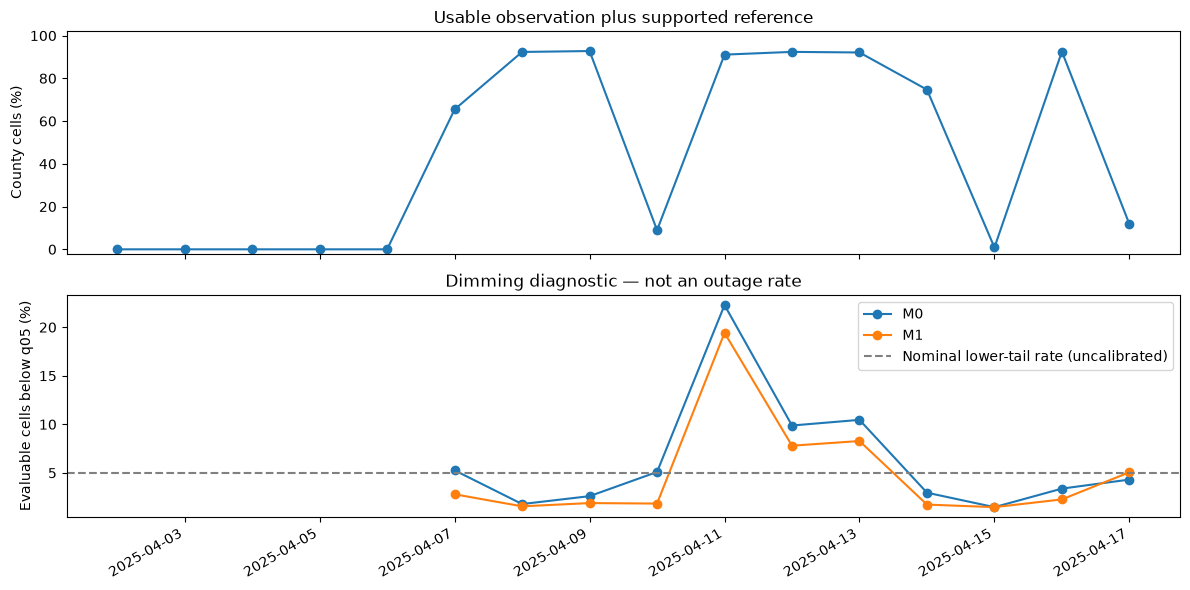

In [4]:
display(event_summary.round(4))
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
availability = event_summary[event_summary['method'] == 'M0']
axes[0].plot(pd.to_datetime(availability['date']), availability['evaluable_cells'] / availability['county_cells'] * 100, 'o-')
axes[0].set(ylabel='County cells (%)', title='Usable observation plus supported reference', ylim=(-2, 102))
for method, part in event_summary.groupby('method'):
    axes[1].plot(pd.to_datetime(part['date']), part['fraction_below_q05'] * 100, 'o-', label=method)
axes[1].axhline(5, color='0.5', linestyle='--', label='Nominal lower-tail rate (uncalibrated)')
axes[1].set(ylabel='Evaluable cells below q05 (%)', title='Dimming diagnostic — not an outage rate')
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Inspect one native cell

The default cell is the brightest supported cell according to its **pre-event median**. Set `CELL_LON_LAT` from QGIS to inspect another location. M1's expected level remains flat after the cutoff because this version has no drift term; its predictive uncertainty expands through elapsed days. M0 and M1 can therefore have different levels and interval widths without either line following the event measurements.

Bands are nominal central 90% predictive intervals. Negative lower bounds reflect the unbounded statistical approximation; exported values are not clipped. Dark cells may be poorly suited to this approximation and to outage detection.

cell_id            h09v05_r0952_c0108
longitude                  -89.547917
latitude                     36.03125
count                              24
supported                        True
baseline_median              0.434024
M0_reference                 0.434024
M1_reference                 0.479399
Name: 4693, dtype: object


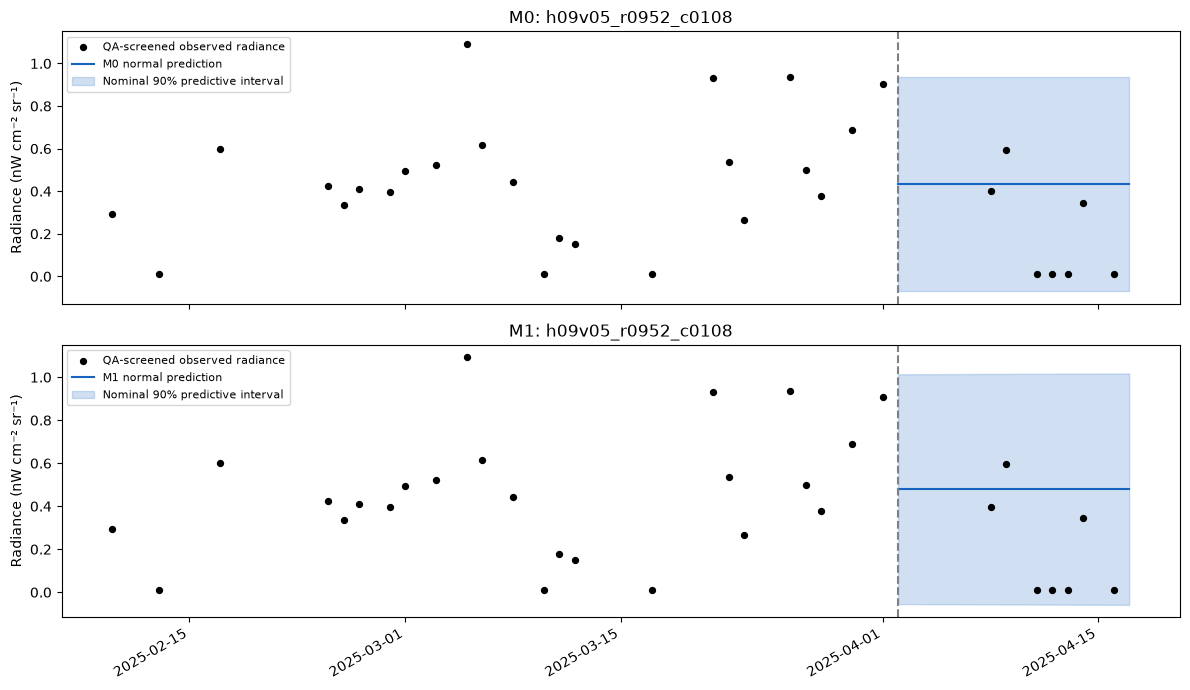

/tmp/ipykernel_6758/25525818.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  **{f'{method}_{key}': arrays[f'{method}_{key}'][:, index] for method in ['M0', 'M1'] for key in ['center', 'q05', 'q95', 'lower_tail']}}).round(4))


,date,observed,M0_center,M0_q05,M0_q95,M0_lower_tail,M1_center,M1_q05,M1_q95,M1_lower_tail
0,2025-04-02,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0549,1.0137,NaN
1,2025-04-03,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0551,1.0139,NaN
2,2025-04-04,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0554,1.0142,NaN
3,2025-04-05,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0556,1.0144,NaN
4,2025-04-06,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0559,1.0147,NaN
5,2025-04-07,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0561,1.0149,NaN
6,2025-04-08,0.3988,0.434,-0.0701,0.9382,0.4528,0.4794,-0.0564,1.0152,0.4007
7,2025-04-09,0.5956,0.434,-0.0701,0.9382,0.7060,0.4794,-0.0566,1.0154,0.6414
8,2025-04-10,NaN,0.434,-0.0701,0.9382,NaN,0.4794,-0.0569,1.0157,NaN
9,2025-04-11,0.0100,0.434,-0.0701,0.9382,0.0815,0.4794,-0.0571,1.0159,0.0743


In [13]:
CELL_LON_LAT = -89.55,36.03  # Example: (-89.39, 36.03)
if CELL_LON_LAT is None:
    index = int(cells.loc[cells['supported'], 'baseline_median'].idxmax())
else:
    r, c = rowcol(affine, *CELL_LON_LAT)
    matched = cells.index[(cells['crop_row'] == r) & (cells['crop_col'] == c)]
    assert len(matched) == 1, 'Choose a native cell with its center inside Dyer'
    index = int(matched[0])
print(cells.loc[index, ['cell_id', 'longitude', 'latitude', 'count', 'supported', 'baseline_median', 'M0_reference', 'M1_reference']])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, method in zip(axes, ['M0', 'M1']):
    ax.scatter(dates, observed[:, index], s=18, color='black', label='QA-screened observed radiance', zorder=3)
    ax.plot(event_dates, arrays[f'{method}_center'][:, index], label=f'{method} normal prediction', color='#1565c0')
    ax.fill_between(event_dates, arrays[f'{method}_q05'][:, index], arrays[f'{method}_q95'][:, index], alpha=.2, color='#1565c0', label='Nominal 90% predictive interval')
    ax.axvline(event_dates[0], color='0.5', linestyle='--')
    ax.set(ylabel='Radiance (nW cm⁻² sr⁻¹)', title=f'{method}: {cells.loc[index, "cell_id"]}')
    ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
display(pd.DataFrame({'date': event_dates, 'observed': observed[cutoff:, index],
                      **{f'{method}_{key}': arrays[f'{method}_{key}'][:, index] for method in ['M0', 'M1'] for key in ['center', 'q05', 'q95', 'lower_tail']}}).round(4))

## Native-grid maps

Blank observed/scored cells lack usable observations or adequate baseline support. Forecast-only values on cloudy nights are available in QGIS, but are not measurements of actual conditions. Standardized residuals use the predictive standard deviation; negative values indicate dimming. The fixed ±3 display scale is for comparison, not a detection threshold.

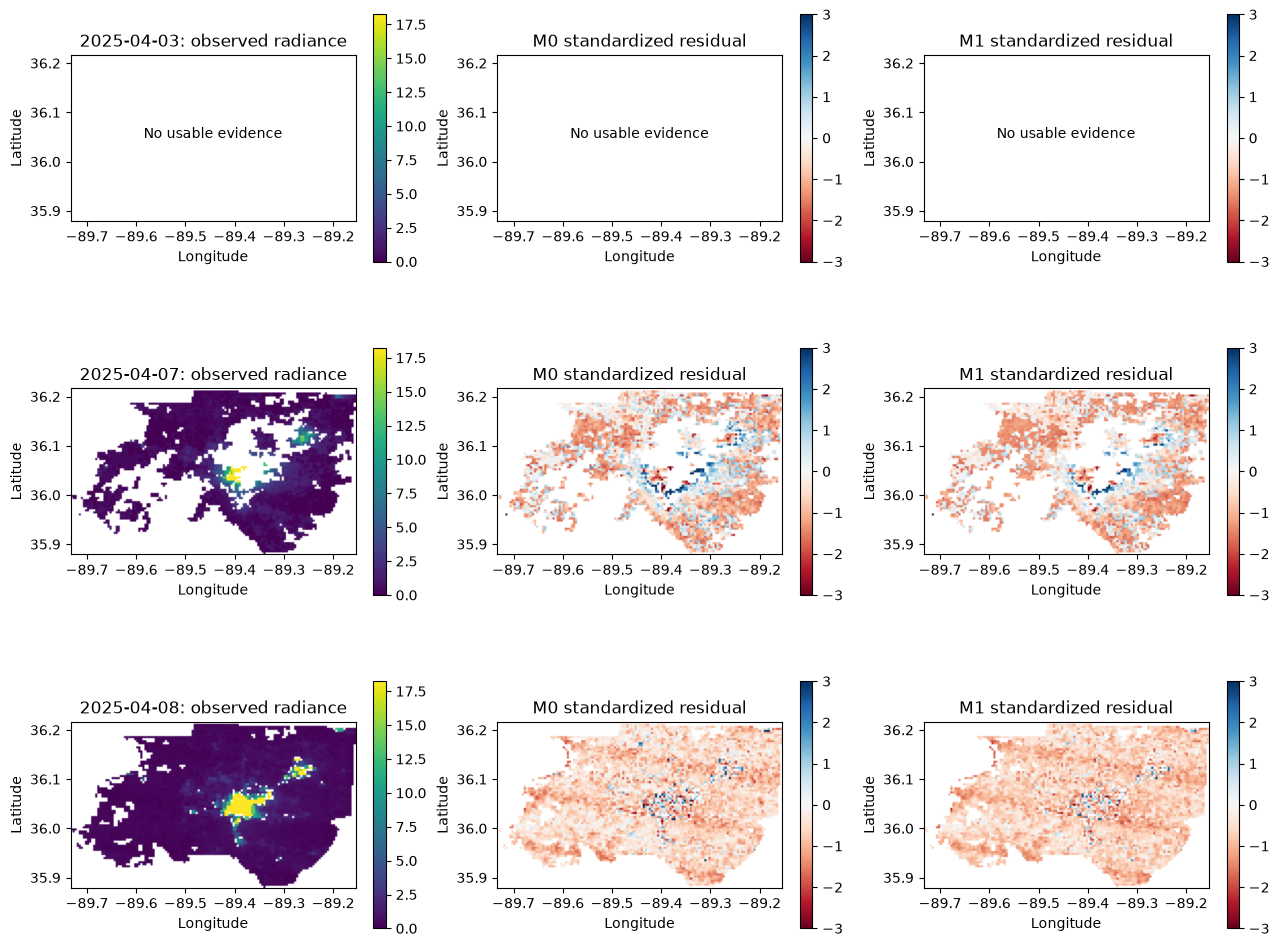

In [14]:
MAP_DATES = ['2025-04-03', '2025-04-07', '2025-04-08']
height, width = county.shape
extent = [affine.c, affine.c + width * affine.a, affine.f + height * affine.e, affine.f]
def grid(values):
    result = np.full(county.shape, np.nan)
    result[county] = values
    return result
vmax = float(cells.loc[cells['supported'], 'baseline_median'].quantile(.98))
fig, axes = plt.subplots(len(MAP_DATES), 3, figsize=(13, 3.5 * len(MAP_DATES)), squeeze=False)
for row, day in enumerate(MAP_DATES):
    k = int(event_dates.get_loc(day))
    values = [observed[cutoff+k], arrays['M0_standardized_residual'][k], arrays['M1_standardized_residual'][k]]
    titles = [f'{day}: observed radiance', 'M0 standardized residual', 'M1 standardized residual']
    for j, (ax, value, title) in enumerate(zip(axes[row], values, titles)):
        im = ax.imshow(grid(value), extent=extent, origin='upper', cmap='viridis' if j == 0 else 'RdBu', vmin=0 if j == 0 else -3, vmax=vmax if j == 0 else 3)
        ax.set(title=title, xlabel='Longitude', ylabel='Latitude')
        fig.colorbar(im, ax=ax, shrink=.7)
        if not np.isfinite(value).any(): ax.text(.5, .5, 'No usable evidence', transform=ax.transAxes, ha='center')
plt.tight_layout()
plt.show()

## QGIS outputs and interpretation

On the Mac mount, open **`~/mnt/ntl/published/counterfactual_dyer/`**:

- `baseline_supported.tif`, `baseline_usable_nights.tif`: reference support.
- `observed/YYYY-MM-DD.tif`: screened, non-gap-filled corrected radiance.
- `M0/daily/YYYY-MM-DD/` and `M1/daily/YYYY-MM-DD/`: `center`, `q05`, `q95`, `residual`, `standardized_residual`, and `lower_tail` COGs.
- `cells.csv`: native source row/column IDs, centers, and model support.
- `event_cell_nights.csv.gz`: complete event cell-night table, including QA and missing-evidence status.

All rasters preserve the source grid. Center and interval rasters can be populated when the observation is missing; residual and tail layers remain blank. Close and reload layers after rerunning the pipeline to avoid stale QGIS caches.

Before choosing a model, inspect whether M1 improves prediction for bright cells, whether either interval has adequate lower-tail calibration, and how much evidence the cloudy event window actually provides. Neither model has been calibrated to TING. Outage-state inference and the reallocation proxy are subsequent steps.